# Detecting edges

## Basic setup

In [19]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

import cv2
import numpy as np
from matplotlib import pyplot as plt

## Loading images

In [20]:
nazwy_plikow = [
    # "../out/image1.jpg",
    # "../out/image2.jpg",
    # "../out/image3.jpg",
    # "../out/image4.jpg",
    # "../out/image5.jpg",
    "../out/image7.jpg",
    "../out/image8.jpg",
    "../out/image9.jpg",
    "../out/image10.jpg"
]

images = []

for file_name in nazwy_plikow:
    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

## Basic constants and functions initialization

In [21]:
main_image = images[0].copy()

def displayTwoImages(images_arr):
    fig.add_subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(images_arr[1])

    fig.add_subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(images_arr[1], cmap=plt.get_cmap('gray'))

## Displaying loaded images

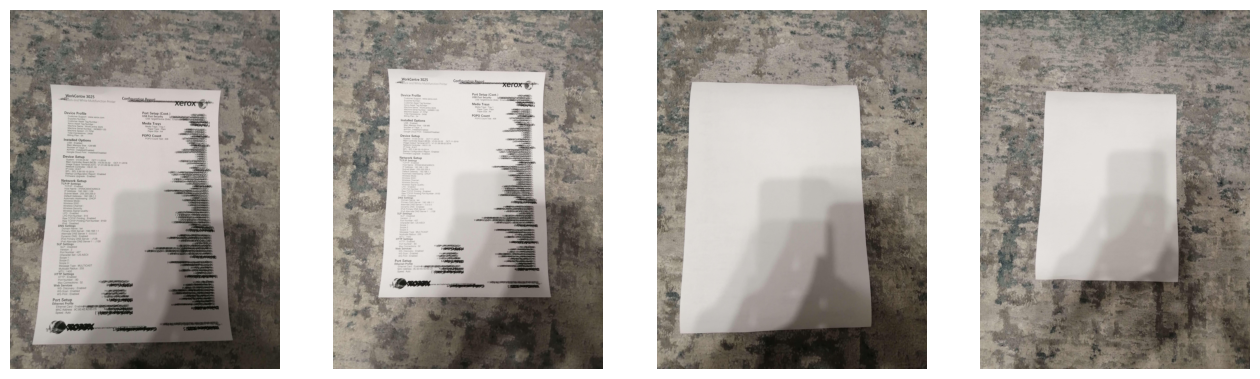

In [22]:
fig = plt.figure(figsize=(16, 8))

for i, img in enumerate(images):
    fig.add_subplot(1, len(images), i + 1)
    
    # plt.imshow(img)
    plt.axis('off')
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    
plt.show()

## HoughLines

In [27]:
def get_hough_lines(edges_cp):
    lines = cv2.HoughLines(edges_cp, 1, np.pi / 180, 100,
                          30, 0, 0, 0, np.pi)
    return lines

def get_image_with_lines(image_cp, lines_cp):
    for rho, theta in lines_cp[0:1000, 0]:
        line_length = 10000
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + line_length*(-b))
        y1 = int(y0 + line_length*(a))
        x2 = int(x0 - line_length*(-b))
        y2 = int(y0 - line_length*(a))
        cv2.line(image_cp, (x1,y1), (x2,y2), (255,0,255), 5)

    return image_cp

def modifyImage_HoughLines(image_cp):
    image_cp = cv2.GaussianBlur(image_cp, (7, 7), 1)
    
    edges = cv2.Canny(image_cp, 150, 200, apertureSize=3)
    
    lines = get_hough_lines(edges)

    # print(len(lines))

    return get_image_with_lines(image_cp, lines)

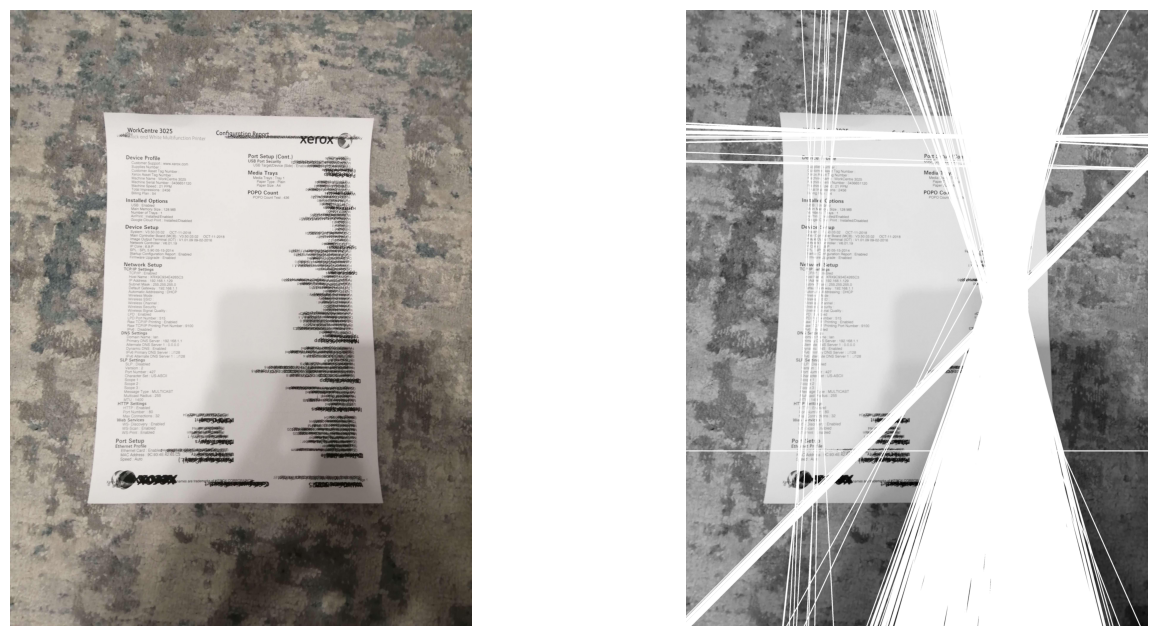

In [28]:
fig = plt.figure(figsize=(16, 8))

img = images[1].copy()
fig.add_subplot(1, 2, 1)
plt.axis('off')
plt.imshow(img)

new_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
new_img = modifyImage_HoughLines(new_img)
fig.add_subplot(1, 2, 2)
plt.axis('off')
plt.imshow(new_img, cmap=plt.get_cmap('gray'))

plt.show()

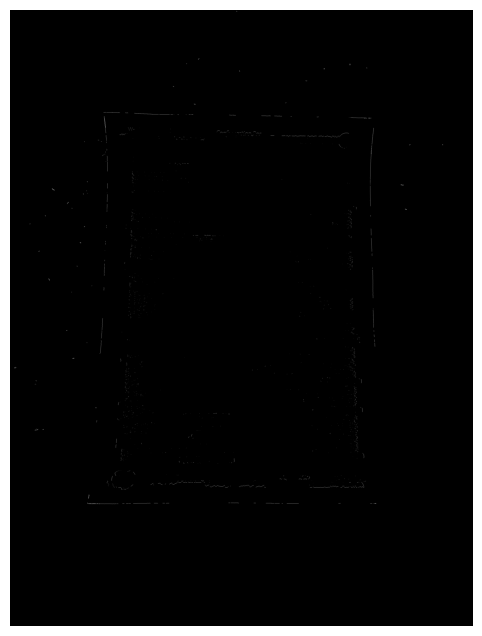

In [31]:
plt.figure(figsize=(16, 8))

new_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
new_img = cv2.GaussianBlur(new_img, (7, 7), 1)
new_img = cv2.Canny(new_img, 150, 200, apertureSize=3)

height, width = new_img.shape

hor_edges = np.zeros((height, width)) # horizontal edges
ver_edges = np.zeros((height, width)) # vertical edges

for row in range(height):

    try:
        f = new_img[row, :].tolist().index(255)
        l = width - new_img[row, :].tolist()[::-1].index(255)

        hor_edges[row, [f, l]] = 255

        # hor_edges[(row - 2):(row + 2), (f - 2):(f + 2)] = 255
        # hor_edges[(row - 2):(row + 2), (l - 2):(l + 2)] = 255
        
    except:
        f = -1
        l = -1

    # print(f, l)

for col in range(width):
    
    try:
        f = new_img[:, col].tolist().index(255)
        l = height - new_img[:, col].tolist()[::-1].index(255)
        
        ver_edges[[f, l], col] = 255
        
        # ver_edges[(f - 2):(f + 2), (col - 2):(col + 2)] = 255
        # ver_edges[(l - 2):(l + 2), (col - 2):(col + 2)] = 255
        
    except:
        f = -1
        l = -1

    # print(f, l)

new_img = np.clip(ver_edges + hor_edges, 0, 255).astype(np.uint8)

plt.axis("off")
plt.imshow(new_img, cmap=plt.get_cmap('gray'))
plt.show()

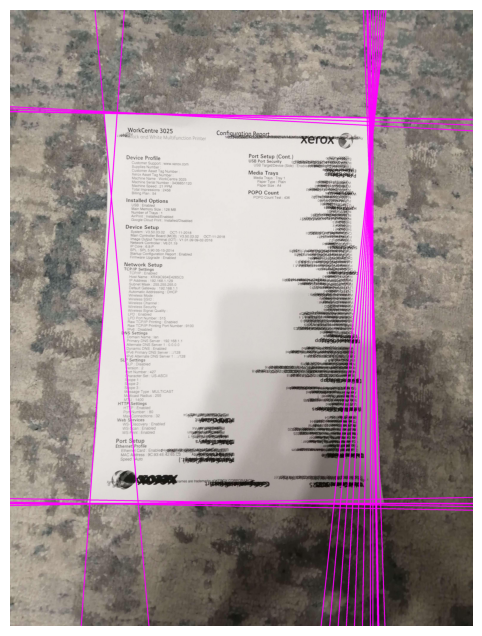

In [32]:
plt.figure(figsize=(16, 8))

lines = get_hough_lines(new_img)
img_with_edges = get_image_with_lines(img.copy(), lines)
plt.axis('off')
plt.imshow(img_with_edges, cmap=plt.get_cmap('gray'))

plt.show()